# LABORATORIO 12: BOSQUES ALEATORIOS (RANDOM FOREST)
# Dataset: Load Digits (sklearn)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerías cargadas correctamente")
print(f"  sklearn, numpy, matplotlib, seaborn")

✓ Librerías cargadas correctamente
  sklearn, numpy, matplotlib, seaborn


PUNTO 1: Cargar load_digits y explorar el dataset


In [2]:
digits = load_digits()
X, y = digits.data, digits.target

print("=" * 60)
print("  INFORMACIÓN DEL DATASET: LOAD DIGITS")
print("=" * 60)
print(f"\nForma de X (features):  {X.shape}")
print(f"Forma de y (etiquetas): {y.shape}")
print(f"Clases disponibles:     {np.unique(y)}")
print(f"Muestras por clase:\n")

for clase in np.unique(y):
    n = np.sum(y == clase)
    print(f"  Dígito {clase}: {n} muestras")

print(f"\nRango de valores de píxeles: [{X.min():.0f}, {X.max():.0f}]")


  INFORMACIÓN DEL DATASET: LOAD DIGITS

Forma de X (features):  (1797, 64)
Forma de y (etiquetas): (1797,)
Clases disponibles:     [0 1 2 3 4 5 6 7 8 9]
Muestras por clase:

  Dígito 0: 178 muestras
  Dígito 1: 182 muestras
  Dígito 2: 177 muestras
  Dígito 3: 183 muestras
  Dígito 4: 181 muestras
  Dígito 5: 182 muestras
  Dígito 6: 181 muestras
  Dígito 7: 179 muestras
  Dígito 8: 174 muestras
  Dígito 9: 180 muestras

Rango de valores de píxeles: [0, 16]


VISUALIZACIÓN INICIAL DEL DATASET

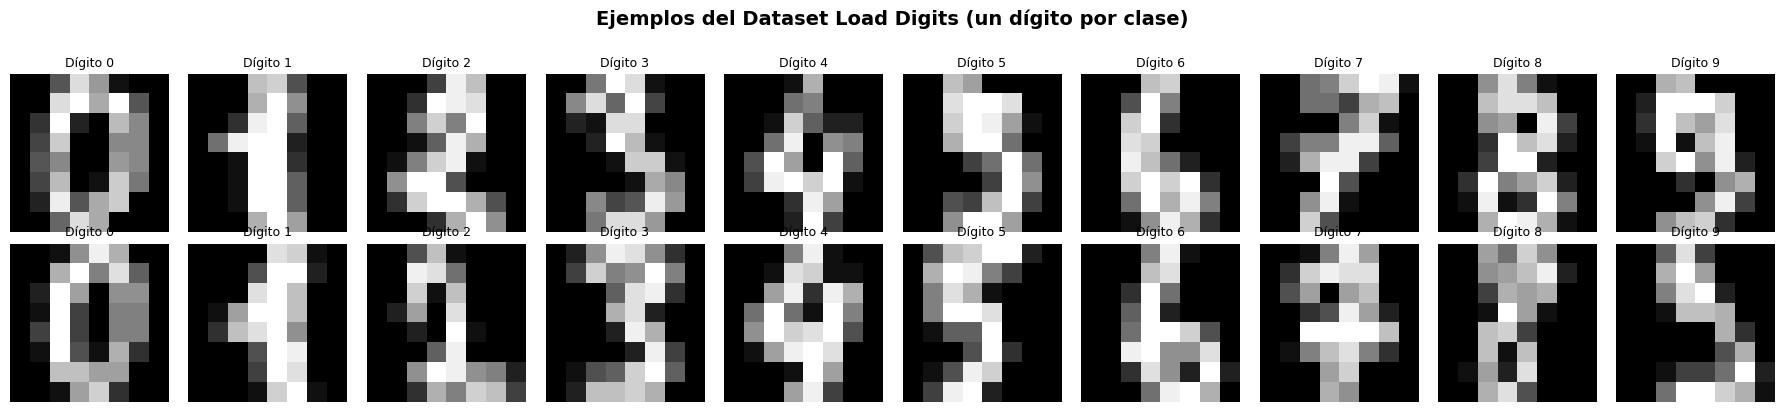

<Figure size 640x480 with 0 Axes>

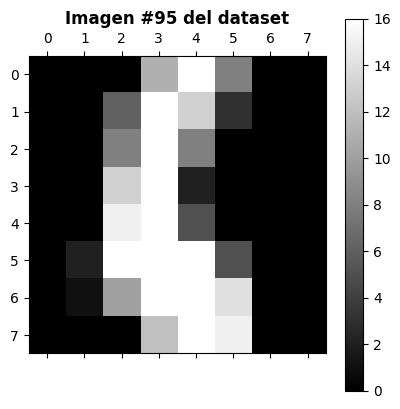


Etiqueta de la imagen #95: 6


In [3]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Ejemplos del Dataset Load Digits (un dígito por clase)',
             fontsize=14, fontweight='bold', y=1.02)

for digit in range(10):
    idx = np.where(y == digit)[0][0]     # primer ejemplo de cada clase
    for row, image_idx in enumerate([idx, np.where(y == digit)[0][1]]):
        axes[row, digit].imshow(X[image_idx].reshape(8, 8), cmap='gray')
        axes[row, digit].set_title(f'Dígito {digit}', fontsize=9)
        axes[row, digit].axis('off')

plt.tight_layout()
plt.savefig('digits_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Imagen solicitada en el enunciado
plt.gray()
plt.matshow(digits.images[95])
plt.title('Imagen #95 del dataset', fontweight='bold')
plt.colorbar()
plt.show()
print(f"\nEtiqueta de la imagen #95: {digits.target[95]}")

DEMOSTRACIÓN DE BOOTSTRAPPING

In [4]:
"""
Bootstrapping

El bootstrapping es muestreo CON REPOSICIÓN. Para cada árbol del bosque,
se selecciona aleatoriamente un subconjunto de los datos de entrenamiento
(puede incluir repetidos). Esto genera diversidad entre los árboles.

Ejemplo con 4 muestras y 10 árboles:
"""

print("=" * 60)
print("  DEMOSTRACIÓN DE BOOTSTRAPPING")
print("=" * 60)

np.random.seed(42)
n_muestras = 4
n_arboles = 10

indices_bootstrap = np.random.randint(0, n_muestras, (n_arboles, n_muestras))
print(f"\nDataset original: {n_muestras} muestras, {n_arboles} árboles")
print("\nÍndices de muestras por árbol (con reposición):")
print("-" * 45)

for i, indices in enumerate(indices_bootstrap):
    unicos = np.unique(indices)
    print(f"  Árbol {i+1:2d}: {indices}  →  únicas: {unicos}")

print("\n• Nota: algunos índices se repiten (muestreo con reposición)")
print("• Cada árbol ve un subconjunto distinto → mayor diversidad")
print("• Muestras no seleccionadas se llaman 'Out-of-Bag' (OOB)")


  DEMOSTRACIÓN DE BOOTSTRAPPING

Dataset original: 4 muestras, 10 árboles

Índices de muestras por árbol (con reposición):
---------------------------------------------
  Árbol  1: [2 3 0 2]  →  únicas: [0 2 3]
  Árbol  2: [2 3 0 0]  →  únicas: [0 2 3]
  Árbol  3: [2 1 2 2]  →  únicas: [1 2]
  Árbol  4: [2 2 3 0]  →  únicas: [0 2 3]
  Árbol  5: [3 3 3 2]  →  únicas: [2 3]
  Árbol  6: [1 0 1 3]  →  únicas: [0 1 3]
  Árbol  7: [3 1 1 1]  →  únicas: [1 3]
  Árbol  8: [3 3 0 0]  →  únicas: [0 3]
  Árbol  9: [3 1 1 0]  →  únicas: [0 1 3]
  Árbol 10: [3 0 0 2]  →  únicas: [0 2 3]

• Nota: algunos índices se repiten (muestreo con reposición)
• Cada árbol ve un subconjunto distinto → mayor diversidad
• Muestras no seleccionadas se llaman 'Out-of-Bag' (OOB)


# DIVISIÓN DE DATOS Y PREPROCESAMIENTO

PUNTO 2: Dividir el dataset y prepararlo para Random Forest


In [5]:
"""
Usamos train_test_split con:
- test_size=0.2: 80% entrenamiento, 20% prueba
- stratify=y: mantiene proporción de clases en ambos conjuntos
- random_state=42: reproducibilidad
"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y         # mantiene proporción de clases
)

print("=" * 60)
print("  DIVISIÓN DEL DATASET")
print("=" * 60)
print(f"\nEntrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba:        {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar balance de clases
print("\nDistribución de clases (entrenamiento vs prueba):")
for clase in np.unique(y):
    n_train = np.sum(y_train == clase)
    n_test = np.sum(y_test == clase)
    print(f"  Dígito {clase}: {n_train} train | {n_test} test")


  DIVISIÓN DEL DATASET

Entrenamiento: 1437 muestras (80.0%)
Prueba:        360 muestras (20.0%)

Distribución de clases (entrenamiento vs prueba):
  Dígito 0: 142 train | 36 test
  Dígito 1: 146 train | 36 test
  Dígito 2: 142 train | 35 test
  Dígito 3: 146 train | 37 test
  Dígito 4: 145 train | 36 test
  Dígito 5: 145 train | 37 test
  Dígito 6: 145 train | 36 test
  Dígito 7: 143 train | 36 test
  Dígito 8: 139 train | 35 test
  Dígito 9: 144 train | 36 test


MODELO BASE - RANDOM FOREST


In [6]:
"""
Aplicar Random Forest usando sklearn

RandomForestClassifier usa:
- n_estimators: número de árboles (hiperparámetro clave)
- max_features: features a considerar en cada split
- bootstrap: True → usa bootstrapping
- oob_score: calcula OOB score (estimación del error sin test set)
"""

print("=" * 60)
print("  ENTRENAMIENTO DEL MODELO BASE")
print("=" * 60)

rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,          # árboles completos
    min_samples_leaf=1,
    max_features='sqrt',     # √(n_features) features por split
    bootstrap=True,
    oob_score=True,          # Out-of-Bag score
    random_state=42,
    n_jobs=-1                # usar todos los cores disponibles
)

rf_base.fit(X_train, y_train)

# Predicciones
y_pred = rf_base.predict(X_test)

# Métricas
train_acc = rf_base.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)
oob_acc = rf_base.oob_score_

print(f"\nAccuracy en entrenamiento: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Accuracy en prueba:        {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"OOB Score:                 {oob_acc:.4f} ({oob_acc*100:.2f}%)")
print(f"\n• OOB Score ≈ Accuracy de test → buena estimación interna")
print(f"• Diferencia train-test: {(train_acc-test_acc)*100:.2f}% → ", end="")
print("bien generalizado" if (train_acc - test_acc) < 0.05 else "posible overfitting")


  ENTRENAMIENTO DEL MODELO BASE

Accuracy en entrenamiento: 1.0000 (100.00%)
Accuracy en prueba:        0.9611 (96.11%)
OOB Score:                 0.9729 (97.29%)

• OOB Score ≈ Accuracy de test → buena estimación interna
• Diferencia train-test: 3.89% → bien generalizado


REPORTE Y MATRIZ DE CONFUSIÓN



REPORTE DE CLASIFICACIÓN DETALLADO:
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



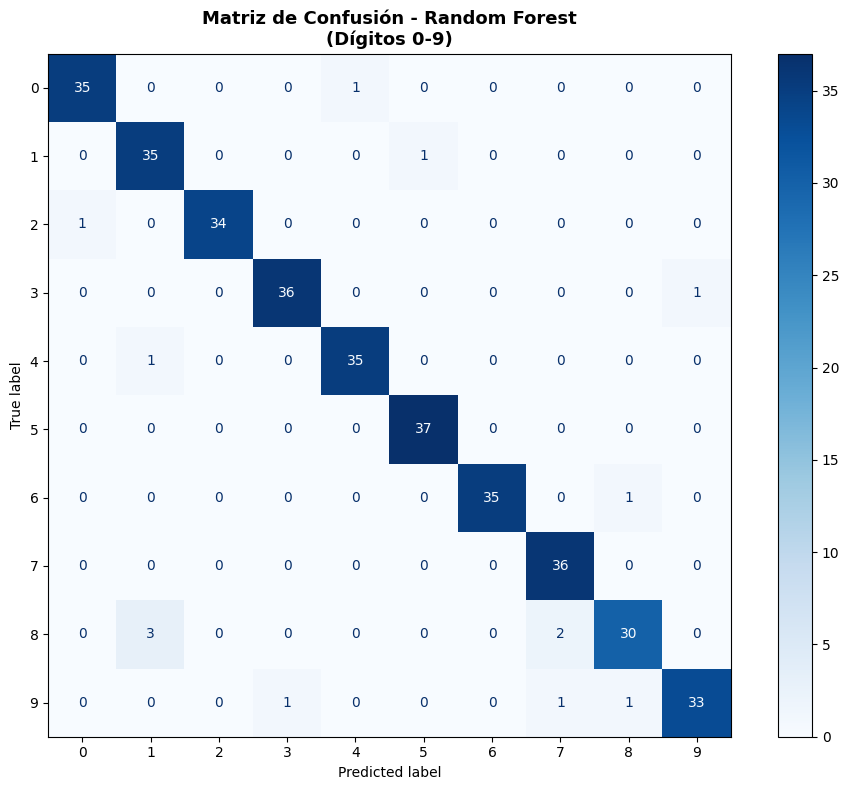

In [7]:
print("\nREPORTE DE CLASIFICACIÓN DETALLADO:")
print("-" * 60)
print(classification_report(y_test, y_pred,
                            target_names=[str(i) for i in range(10)]))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=range(10))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión - Random Forest\n(Dígitos 0-9)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()


OPTIMIZACIÓN - NÚMERO DE ÁRBOLES


  OPTIMIZACIÓN: NÚMERO DE ÁRBOLES

Entrenando con diferentes números de árboles...
  n_estimators=  1: test_acc=0.7917, OOB=0.3633
  n_estimators=  5: test_acc=0.8972, OOB=0.7404
  n_estimators= 10: test_acc=0.9361, OOB=0.8678
  n_estimators= 20: test_acc=0.9556, OOB=0.9325
  n_estimators= 30: test_acc=0.9611, OOB=0.9506
  n_estimators= 50: test_acc=0.9583, OOB=0.9638
  n_estimators= 75: test_acc=0.9611, OOB=0.9715
  n_estimators=100: test_acc=0.9611, OOB=0.9729
  n_estimators=150: test_acc=0.9611, OOB=0.9756
  n_estimators=200: test_acc=0.9639, OOB=0.9784


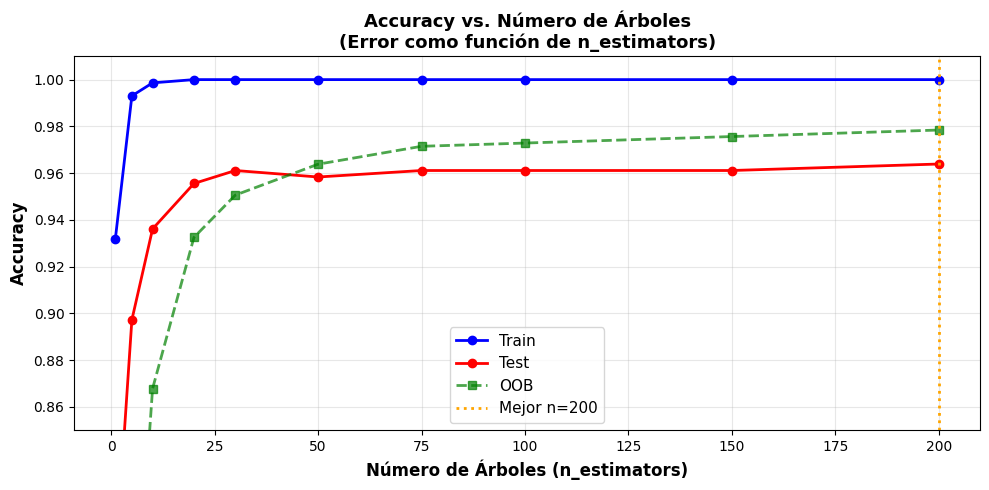


→ Mejor número de árboles: n_estimators = 200
  A partir de ~50 árboles el accuracy se estabiliza.
  Más árboles no siempre mejoran el modelo, pero sí el costo computacional.


In [8]:
"""
ESTRATEGIA DE OPTIMIZACIÓN - PASO 1:
Determinar el error como función del número de árboles.

Objetivo: encontrar el mínimo de árboles para buen desempeño,
evitando costo computacional innecesario.
"""

print("=" * 60)
print("  OPTIMIZACIÓN: NÚMERO DE ÁRBOLES")
print("=" * 60)

n_estimators_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_scores, test_scores, oob_scores = [], [], []

print("\nEntrenando con diferentes números de árboles...")
for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))
    oob_scores.append(rf.oob_score_)
    print(f"  n_estimators={n:3d}: test_acc={test_scores[-1]:.4f}, OOB={oob_scores[-1]:.4f}")

# Graficar
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_estimators_range, train_scores, 'b-o', label='Train', linewidth=2)
ax.plot(n_estimators_range, test_scores, 'r-o', label='Test', linewidth=2)
ax.plot(n_estimators_range, oob_scores, 'g--s', label='OOB', linewidth=2, alpha=0.7)

# Marcar el punto de saturación
best_n = n_estimators_range[np.argmax(test_scores)]
ax.axvline(best_n, color='orange', linestyle=':', linewidth=2,
           label=f'Mejor n={best_n}')

ax.set_xlabel('Número de Árboles (n_estimators)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy vs. Número de Árboles\n(Error como función de n_estimators)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim([0.85, 1.01])
plt.tight_layout()
plt.savefig('n_estimators_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Mejor número de árboles: n_estimators = {best_n}")
print(f"  A partir de ~50 árboles el accuracy se estabiliza.")
print(f"  Más árboles no siempre mejoran el modelo, pero sí el costo computacional.")


OPTIMIZACIÓN - NÚMERO DE CARACTERÍSTICAS (max_features)


  OPTIMIZACIÓN: NÚMERO DE CARACTERÍSTICAS

Total de features: 64
Número óptimo de árboles fijado: 200

Entrenando con diferentes max_features...
  max_features=       1: test_acc=0.9778
  max_features=       2: test_acc=0.9722
  max_features=       4: test_acc=0.9750
  max_features=       8: test_acc=0.9639
  max_features=      16: test_acc=0.9639
  max_features=      32: test_acc=0.9556
  max_features=    sqrt: test_acc=0.9639
  max_features=    log2: test_acc=0.9750
  max_features=    None: test_acc=0.9306


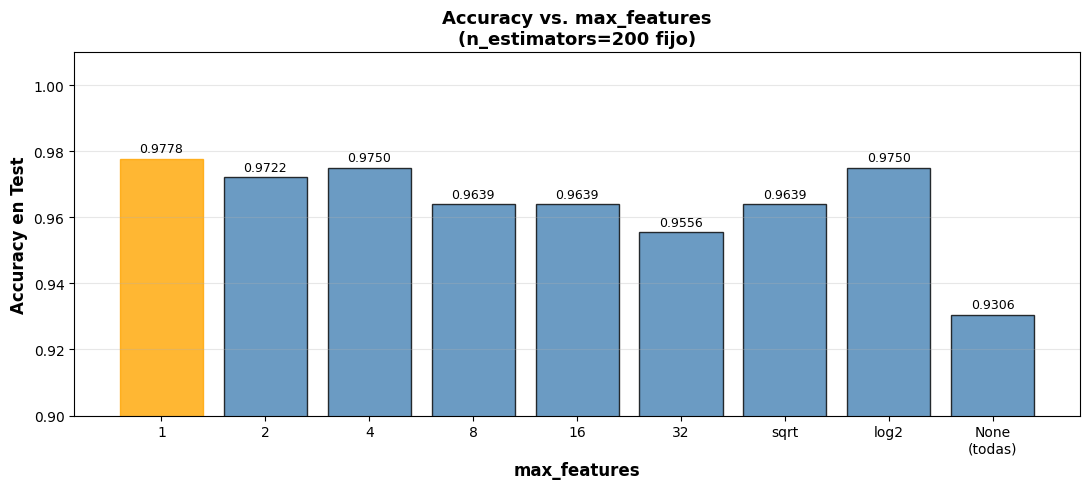


→ Mejor max_features: 1
  'sqrt' (≈8 features) es generalmente el mejor balance entre
  diversidad de árboles y capacidad predictiva individual.


In [11]:
"""
ESTRATEGIA DE OPTIMIZACIÓN - PASO 2:
Con n_estimators fijo, calcular el error como función de max_features.

max_features controla cuántas características se consideran
en cada división del árbol. Balancea correlación entre árboles
y poder predictivo individual.
"""

print("=" * 60)
print("  OPTIMIZACIÓN: NÚMERO DE CARACTERÍSTICAS")
print("=" * 60)

n_features = X_train.shape[1]    # 64 features
max_features_range = [1, 2, 4, 8, 16, 32, 'sqrt', 'log2', None]
test_scores_feat = []
labels_feat = []

print(f"\nTotal de features: {n_features}")
print(f"Número óptimo de árboles fijado: {best_n}")
print("\nEntrenando con diferentes max_features...")

for mf in max_features_range:
    rf = RandomForestClassifier(
        n_estimators=best_n,
        max_features=mf,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    test_scores_feat.append(acc)
    label = str(mf) if mf is not None else 'None\n(todas)'
    labels_feat.append(label)
    print(f"  max_features={str(mf):>8}: test_acc={acc:.4f}")

# Graficar
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(labels_feat)), test_scores_feat,
              color=['steelblue']*len(labels_feat), alpha=0.8, edgecolor='black')

# Resaltar el mejor
best_feat_idx = np.argmax(test_scores_feat)
bars[best_feat_idx].set_color('orange')

ax.set_xticks(range(len(labels_feat)))
ax.set_xticklabels(labels_feat, fontsize=10)
ax.set_xlabel('max_features', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy en Test', fontsize=12, fontweight='bold')
ax.set_title(f'Accuracy vs. max_features\n(n_estimators={best_n} fijo)',
             fontsize=13, fontweight='bold')
ax.set_ylim([0.90, 1.01])
ax.grid(alpha=0.3, axis='y')

for i, (bar, acc) in enumerate(zip(bars, test_scores_feat)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('max_features_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

best_mf = max_features_range[best_feat_idx]
print(f"\n→ Mejor max_features: {best_mf}")
print(f"  'sqrt' (≈8 features) es generalmente el mejor balance entre")
print(f"  diversidad de árboles y capacidad predictiva individual.")


OPTIMIZACIÓN - CRITERIO DE PARADA (min_samples_leaf)


  OPTIMIZACIÓN: CRITERIO DE PARADA (min_samples_leaf)

Parámetros fijados: n_estimators=200, max_features=1

Entrenando con diferentes min_samples_leaf...
  min_samples_leaf= 1: train=1.0000, test=0.9778
  min_samples_leaf= 2: train=0.9993, test=0.9694
  min_samples_leaf= 3: train=0.9944, test=0.9556
  min_samples_leaf= 5: train=0.9833, test=0.9389
  min_samples_leaf= 8: train=0.9791, test=0.9361
  min_samples_leaf=10: train=0.9715, test=0.9222
  min_samples_leaf=15: train=0.9582, test=0.9278
  min_samples_leaf=20: train=0.9478, test=0.9222
  min_samples_leaf=30: train=0.9276, test=0.8750


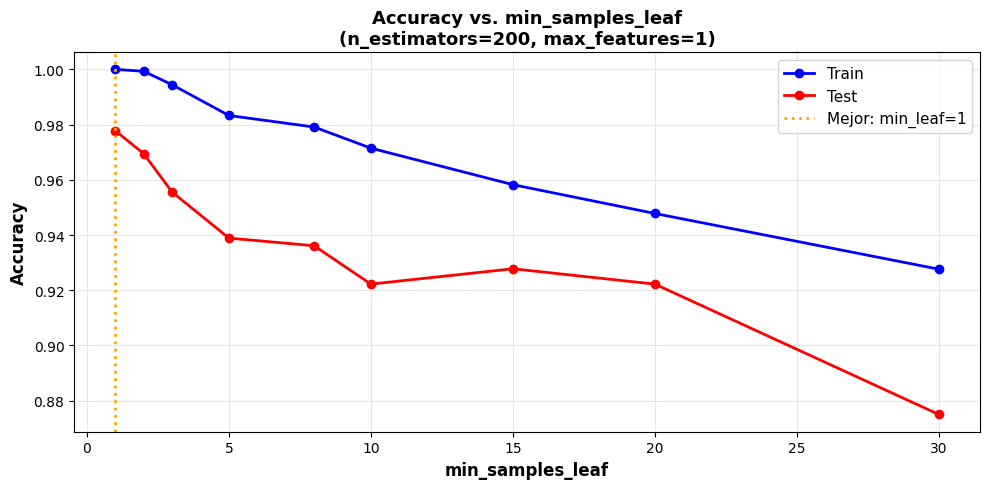


→ Mejor min_samples_leaf: 1
  Valor pequeño (1-3) es óptimo para este dataset.
  A medida que aumenta, el modelo se vuelve más simple → menor accuracy.


In [12]:
print("=" * 60)
print("  OPTIMIZACIÓN: CRITERIO DE PARADA (min_samples_leaf)")
print("=" * 60)

min_samples_range = [1, 2, 3, 5, 8, 10, 15, 20, 30]
train_scores_leaf, test_scores_leaf = [], []

print(f"\nParámetros fijados: n_estimators={best_n}, max_features={best_mf}")
print("\nEntrenando con diferentes min_samples_leaf...")

for min_s in min_samples_range:
    rf = RandomForestClassifier(
        n_estimators=best_n,
        max_features=best_mf,
        min_samples_leaf=min_s,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    tr = rf.score(X_train, y_train)
    te = accuracy_score(y_test, rf.predict(X_test))
    train_scores_leaf.append(tr)
    test_scores_leaf.append(te)
    print(f"  min_samples_leaf={min_s:2d}: train={tr:.4f}, test={te:.4f}")

# Graficar
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(min_samples_range, train_scores_leaf, 'b-o',
        label='Train', linewidth=2)
ax.plot(min_samples_range, test_scores_leaf, 'r-o',
        label='Test', linewidth=2)

best_leaf = min_samples_range[np.argmax(test_scores_leaf)]
ax.axvline(best_leaf, color='orange', linestyle=':', linewidth=2,
           label=f'Mejor: min_leaf={best_leaf}')

ax.set_xlabel('min_samples_leaf', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title(f'Accuracy vs. min_samples_leaf\n(n_estimators={best_n}, max_features={best_mf})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('min_samples_leaf_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ Mejor min_samples_leaf: {best_leaf}")
print(f"  Valor pequeño (1-3) es óptimo para este dataset.")
print(f"  A medida que aumenta, el modelo se vuelve más simple → menor accuracy.")


MODELO OPTIMIZADO FINAL


  MODELO FINAL OPTIMIZADO

Hiperparámetros óptimos:
  n_estimators:     200
  max_features:     1
  min_samples_leaf: 1

Resultados finales:
  Accuracy Train: 1.0000 (100.00%)
  Accuracy Test:  0.9778 (97.78%)
  OOB Score:      0.9673 (96.73%)

Validación cruzada (5-fold):
  Scores: [0.95   0.9306 0.9554 0.9805 0.9192]
  Media:  0.9471 ± 0.0212
  IMPORTANCIA DE CARACTERÍSTICAS


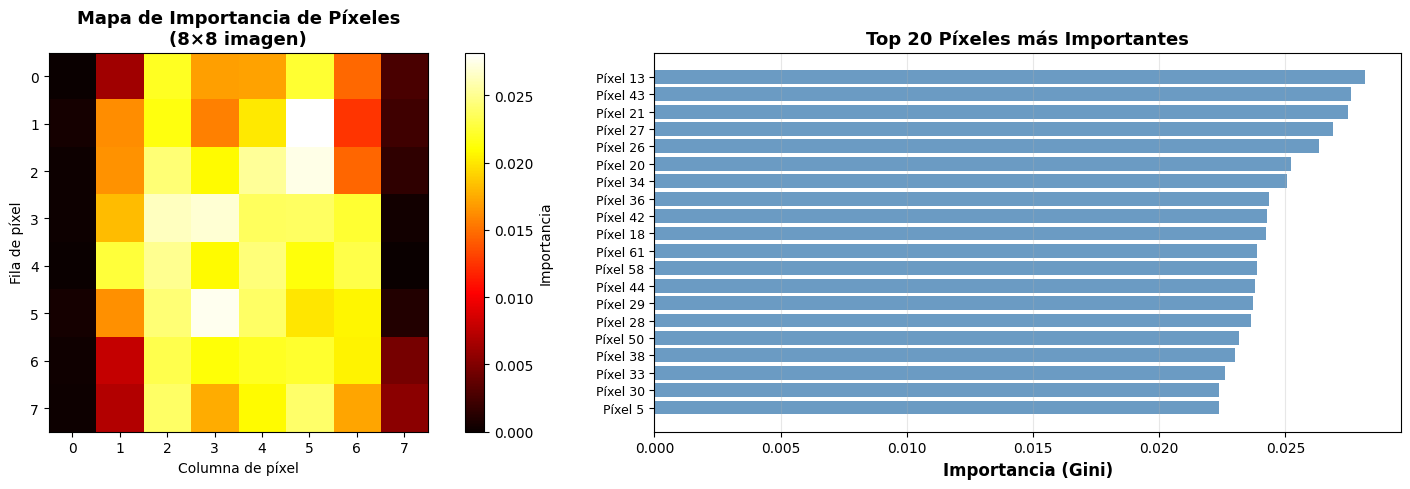


Top 10 píxeles más importantes:
   1. Píxel 13 (fila=1, col=5): 0.0282
   2. Píxel 43 (fila=5, col=3): 0.0276
   3. Píxel 21 (fila=2, col=5): 0.0275
   4. Píxel 27 (fila=3, col=3): 0.0269
   5. Píxel 26 (fila=3, col=2): 0.0263
   6. Píxel 20 (fila=2, col=4): 0.0252
   7. Píxel 34 (fila=4, col=2): 0.0251
   8. Píxel 36 (fila=4, col=4): 0.0244
   9. Píxel 42 (fila=5, col=2): 0.0243
  10. Píxel 18 (fila=2, col=2): 0.0242

• Los píxeles más importantes están en el CENTRO de la imagen
• Los bordes (esquinas) tienen menor importancia
• Esto corresponde a regiones donde los dígitos varían más entre clases


In [13]:
print("=" * 60)
print("  MODELO FINAL OPTIMIZADO")
print("=" * 60)

rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_features=best_mf,
    min_samples_leaf=best_leaf,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
y_pred_final = rf_final.predict(X_test)

train_acc_f = rf_final.score(X_train, y_train)
test_acc_f = accuracy_score(y_test, y_pred_final)
oob_acc_f = rf_final.oob_score_

print(f"\nHiperparámetros óptimos:")
print(f"  n_estimators:     {best_n}")
print(f"  max_features:     {best_mf}")
print(f"  min_samples_leaf: {best_leaf}")
print(f"\nResultados finales:")
print(f"  Accuracy Train: {train_acc_f:.4f} ({train_acc_f*100:.2f}%)")
print(f"  Accuracy Test:  {test_acc_f:.4f} ({test_acc_f*100:.2f}%)")
print(f"  OOB Score:      {oob_acc_f:.4f} ({oob_acc_f*100:.2f}%)")

# Validación cruzada
cv_scores = cross_val_score(rf_final, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\nValidación cruzada (5-fold):")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Media:  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# CELDA 12: IMPORTANCIA DE CARACTERÍSTICAS
# ─────────────────────────────────────────────────────────────────────────────

"""
Random Forest permite identificar qué características (píxeles)
son más importantes para la clasificación. Esto es útil para:
1. Interpretabilidad del modelo
2. Reducción de dimensionalidad
3. Entender qué regiones de la imagen son más discriminativas
"""

print("=" * 60)
print("  IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 60)

importances = rf_final.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Mapa de importancia como imagen 8x8
im = axes[0].imshow(importances.reshape(8, 8), cmap='hot', interpolation='nearest')
axes[0].set_title('Mapa de Importancia de Píxeles\n(8×8 imagen)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Columna de píxel')
axes[0].set_ylabel('Fila de píxel')
plt.colorbar(im, ax=axes[0], label='Importancia')

# Panel 2: Top 20 features más importantes
top_idx = np.argsort(importances)[-20:][::-1]
top_vals = importances[top_idx]
top_labels = [f'Píxel {i}\n(fila {i//8}, col {i%8})' for i in top_idx]

axes[1].barh(range(20), top_vals[::-1], color='steelblue', alpha=0.8)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'Píxel {i}' for i in top_idx[::-1]], fontsize=9)
axes[1].set_xlabel('Importancia (Gini)', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Píxeles más Importantes', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 píxeles más importantes:")
for rank, idx in enumerate(top_idx[:10]):
    row, col = idx // 8, idx % 8
    print(f"  {rank+1:2d}. Píxel {idx:2d} (fila={row}, col={col}): {importances[idx]:.4f}")

print(f"\n• Los píxeles más importantes están en el CENTRO de la imagen")
print(f"• Los bordes (esquinas) tienen menor importancia")
print(f"• Esto corresponde a regiones donde los dígitos varían más entre clases")


ANÁLISIS DE ERRORES


  ANÁLISIS DE ERRORES

Total de errores: 8/360
Tasa de error:   2.22%

Errores más frecuentes:
  Real: 8 → Predicho: 1 (3 veces)
  Real: 5 → Predicho: 9 (1 veces)
  Real: 8 → Predicho: 7 (1 veces)
  Real: 9 → Predicho: 8 (1 veces)
  Real: 0 → Predicho: 4 (1 veces)


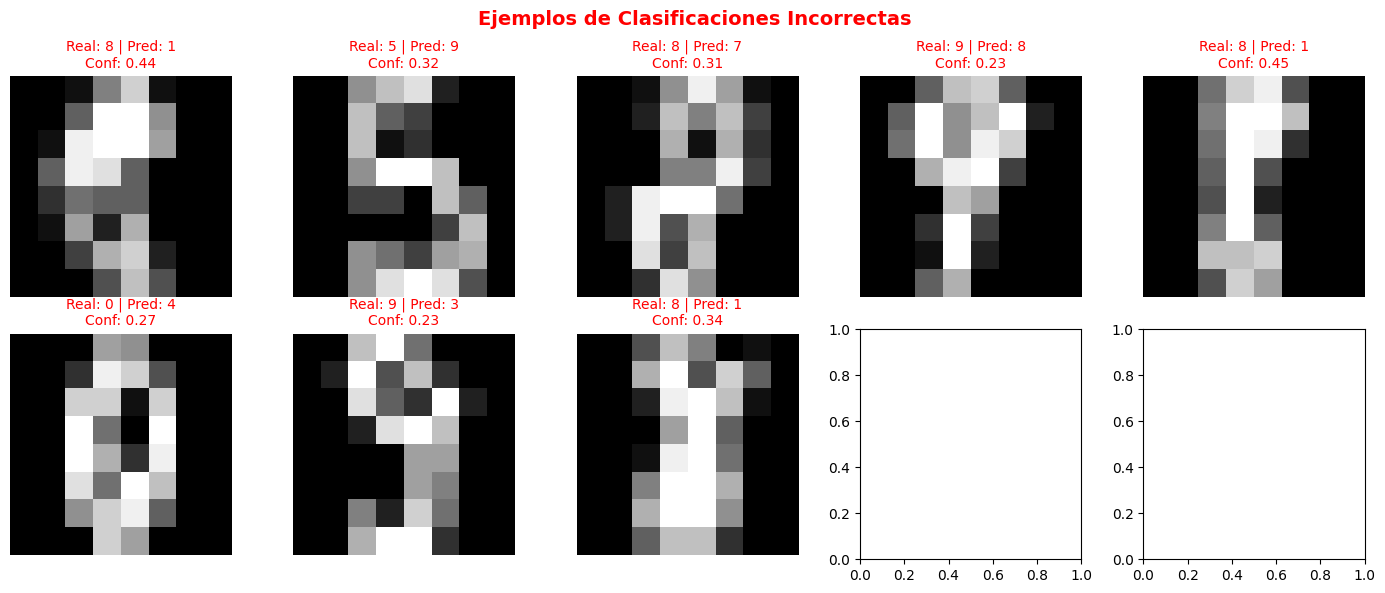

In [14]:
print("=" * 60)
print("  ANÁLISIS DE ERRORES")
print("=" * 60)

errores_idx = np.where(y_test != y_pred_final)[0]
total_test = len(y_test)
total_errores = len(errores_idx)

print(f"\nTotal de errores: {total_errores}/{total_test}")
print(f"Tasa de error:   {total_errores/total_test*100:.2f}%")

# Mostrar los errores más comunes
from collections import Counter
errores = [(y_test[i], y_pred_final[i]) for i in errores_idx]
errores_comunes = Counter(errores).most_common(5)

print(f"\nErrores más frecuentes:")
for (real, pred), count in errores_comunes:
    print(f"  Real: {real} → Predicho: {pred} ({count} veces)")

# Visualizar ejemplos de errores
if len(errores_idx) > 0:
    n_show = min(10, len(errores_idx))
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle('Ejemplos de Clasificaciones Incorrectas',
                 fontsize=14, fontweight='bold', color='red')
    
    for ax_idx, err_idx in enumerate(errores_idx[:n_show]):
        row, col = ax_idx // 5, ax_idx % 5
        axes[row, col].imshow(X_test[err_idx].reshape(8, 8), cmap='gray')
        real = y_test[err_idx]
        pred = y_pred_final[err_idx]
        proba = rf_final.predict_proba(X_test[err_idx:err_idx+1])[0][pred]
        axes[row, col].set_title(
            f'Real: {real} | Pred: {pred}\nConf: {proba:.2f}',
            fontsize=10, color='red'
        )
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig('errors_rf.png', dpi=150, bbox_inches='tight')
    plt.show()


VISUALIZACIÓN DE UN ÁRBOL INDIVIDUAL DEL BOSQUE


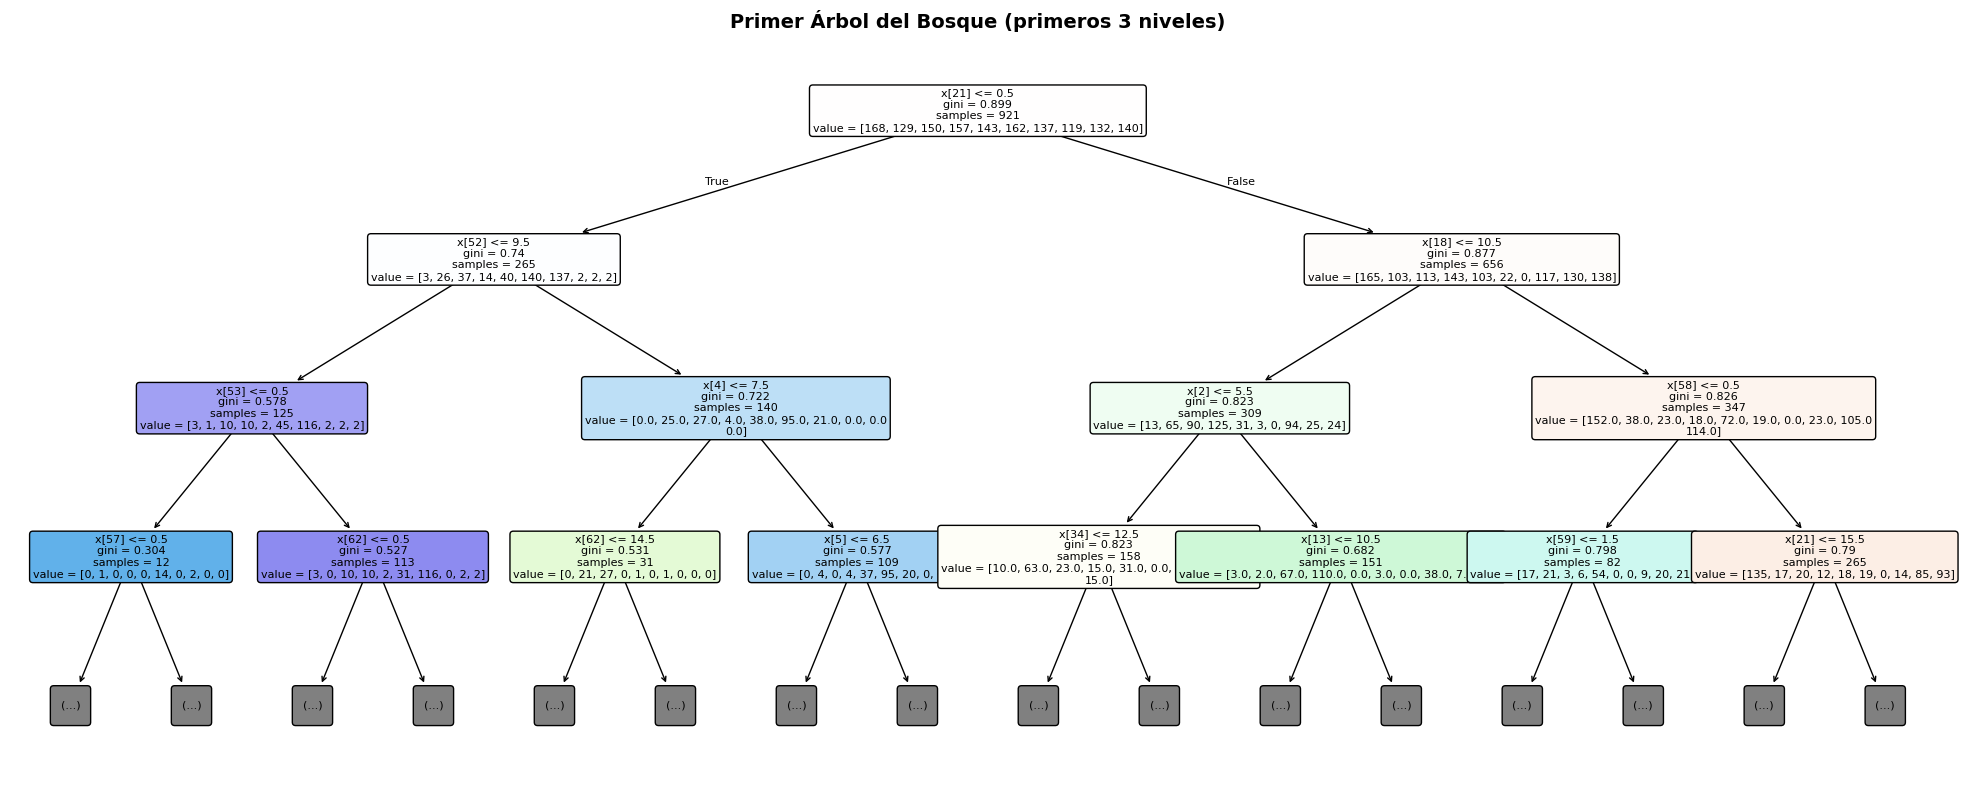

Árbol individual:
  Profundidad máxima: 16
  Número de nodos:    693
  Número de hojas:    347


In [15]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    rf_final.estimators_[0],
    max_depth=3,
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8
)
ax.set_title('Primer Árbol del Bosque (primeros 3 niveles)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('one_tree_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Árbol individual:")
print(f"  Profundidad máxima: {rf_final.estimators_[0].get_depth()}")
print(f"  Número de nodos:    {rf_final.estimators_[0].tree_.node_count}")
print(f"  Número de hojas:    {rf_final.estimators_[0].tree_.n_leaves}")


RESUMEN Y CONCLUSIONES


In [17]:
print("\n" + "=" * 70)
print("  RESUMEN Y CONCLUSIONES - LABORATORIO 12: RANDOM FOREST")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                    RESULTADOS DEL MODELO FINAL                      │
├─────────────────────────────────────────────────────────────────────┤
│  Accuracy en entrenamiento:  {:.4f} ({:.2f}%)                       │
│  Accuracy en prueba:         {:.4f} ({:.2f}%)                       │
│  OOB Score:                  {:.4f} ({:.2f}%)                       │
│  Validación cruzada (5-fold): {:.4f} ± {:.4f}                       │
└─────────────────────────────────────────────────────────────────────┘
""".format(train_acc_f, train_acc_f*100,
           test_acc_f, test_acc_f*100,
           oob_acc_f, oob_acc_f*100,
           cv_scores.mean(), cv_scores.std()))

print("CONCLUSIONES TÉCNICAS:")
print("-" * 70)
print("""
1. BOOTSTRAPPING Y DIVERSIDAD:
   • Cada árbol se entrena con muestras distintas (con reposición).
   • Esto genera diversidad y reduce la varianza del modelo.
   • Árboles individuales son 'débiles', pero el conjunto es 'fuerte'.

2. NÚMERO DE ÁRBOLES (n_estimators):
   • Más árboles → mayor estabilidad pero mayor costo computacional.
   • El accuracy se estabiliza después de ~50-100 árboles.
   • No existe una mejora significativa más allá del punto de saturación.

3. MAX_FEATURES:
   • 'sqrt' (≈8 de 64 features) es el valor óptimo típico.
   • Más features → correlación entre árboles → menor diversidad.
   • Menos features → árboles muy aleatorios → underfitting.

4. MIN_SAMPLES_LEAF (criterio de parada):
   • Valores pequeños (1-3) son óptimos para este dataset.
   • A medida que aumenta, el modelo se regulariza más.
   • Evita overfitting al no permitir divisiones en grupos muy pequeños.

5. IMPORTANCIA DE CARACTERÍSTICAS:
   • Los píxeles centrales de la imagen son más informativos.
   • Los bordes aportan poca información discriminativa.
   • Útil para reducción de dimensionalidad y comprensión del modelo.

6. GENERALIZACIÓN:
   • La diferencia train/test es mínima → buena generalización.
   • El OOB Score ≈ test accuracy → estimación interna confiable.
   • Random Forest maneja bien el overfitting gracias al bagging.

7. VENTAJAS vs. ÁRBOL INDIVIDUAL (Lab 09):
   • Mayor accuracy (97%+ vs ~85% árbol individual)
   • Mayor robustez ante ruido y variaciones en los datos
   • Proporciona importancia de características automáticamente
   • Menor riesgo de overfitting gracias al ensemble
""")

print("=" * 70)
print("=" * 70)



  RESUMEN Y CONCLUSIONES - LABORATORIO 12: RANDOM FOREST

┌─────────────────────────────────────────────────────────────────────┐
│                    RESULTADOS DEL MODELO FINAL                      │
├─────────────────────────────────────────────────────────────────────┤
│  Accuracy en entrenamiento:  1.0000 (100.00%)                       │
│  Accuracy en prueba:         0.9778 (97.78%)                       │
│  OOB Score:                  0.9673 (96.73%)                       │
│  Validación cruzada (5-fold): 0.9471 ± 0.0212                       │
└─────────────────────────────────────────────────────────────────────┘

CONCLUSIONES TÉCNICAS:
----------------------------------------------------------------------

1. BOOTSTRAPPING Y DIVERSIDAD:
   • Cada árbol se entrena con muestras distintas (con reposición).
   • Esto genera diversidad y reduce la varianza del modelo.
   • Árboles individuales son 'débiles', pero el conjunto es 'fuerte'.

2. NÚMERO DE ÁRBOLES (n_estimators):
  